In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier, DMatrix
import xgboost as xgb
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

In [2]:
train = pd.read_parquet('merge/result/Segment_merge_ver_05.parquet')
test = pd.read_parquet('merge/result/Segment_merge_test_ver_05.parquet')

In [3]:
# tqdm 적용한 GridSearchCV 클래스
class TQDMGridSearchCV(GridSearchCV):
    def fit(self, X, y, **fit_params):
        total_combinations = 1
        for v in self.param_grid.values():
            total_combinations *= len(v)
        with tqdm(total=total_combinations, desc="GridSearchCV") as pbar:
            self._pbar = pbar
            return super().fit(X, y, **fit_params)

    def _run_search(self, evaluate_candidates):
        def wrapped(candidate_params):
            results = evaluate_candidates(candidate_params)
            self._pbar.update(len(candidate_params))
            return results
        super()._run_search(wrapped)

In [4]:
# ID별로 그룹화해서 평균값 계산
test_grouped = test.groupby('ID').mean(numeric_only=True).reset_index()

In [5]:
# X, y 분리
X_train = train.drop(columns=['ID', 'Segment'])
y_train = train['Segment']
X_test = test.drop(columns=['ID'])
X_test = X_test[X_train.columns]  

# 라벨 인코딩
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

# 하이퍼파라미터 설정
param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0]
}

In [6]:
# 모델 정의 (GPU 사용)
xgb_clf = XGBClassifier(
    tree_method='hist',
    device='cuda',
    eval_metric='mlogloss',
    random_state=42
)

In [7]:
# GridSearchCV 실행
grid = TQDMGridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    verbose=0,
    n_jobs=1  
)

In [8]:
# 학습 시작
grid.fit(X_train, y_train_encoded)

C:\Users\Lee\anaconda3\envs\tensorflow_env\lib\site-packages\xgboost\core.py:729: UserWarning: [09:48:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
GridSearchCV: 100%|████████████████████████████████████████████████████████████████████| 16/16 [18:43<00:00, 70.23s/it]


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'n_estimators': [100, 200], 'subsample': [0.8, 1.0]}"
,scoring,'accuracy'
,n_jobs,1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softprob'


In [9]:
# 최적 모델 추출
best_model = grid.best_estimator_

In [10]:
# X_train과 컬럼 정렬 맞추기 (Segment 없는 버전)
X_test_grouped = test_grouped[X_train.columns] 
# numpy로 변환 (예: GPU 예측을 위함)
X_test_np = X_test_grouped.to_numpy().astype(np.float32)

In [11]:
# 예측 
y_pred = best_model.predict(X_test_np)

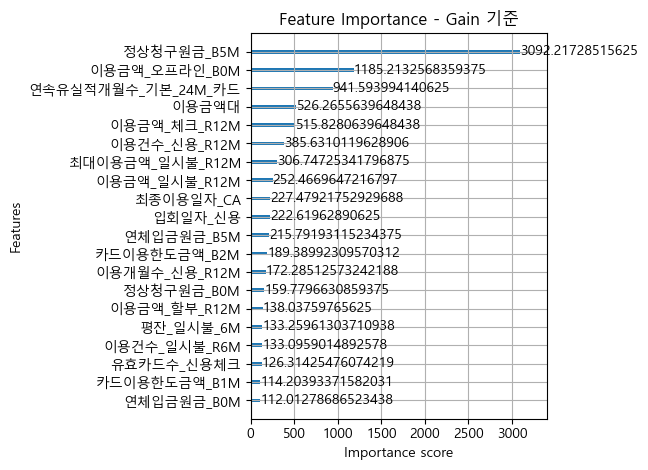

In [12]:
# 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 중요도 시각화
xgb.plot_importance(best_model, importance_type='gain', max_num_features=20)
plt.title("Feature Importance - Gain 기준")
plt.tight_layout()
plt.show()

In [13]:
# 결과 정수화 및 라벨 복원
y_pred_class = np.round(y_pred).astype(int)
y_pred_label = le.inverse_transform(y_pred_class)

In [14]:
# 최적 파라미터 출력
print("Best Parameters:", grid.best_params_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


In [15]:
# 결과 저장
result = pd.DataFrame({
    'ID': test_grouped['ID'],
    'Predicted_Segment': y_pred_label
})
result.to_csv("merge/result/H2_XGB_파라미터튜닝_평균값.csv", index=False)

In [16]:
# 모델 저장
best_model.save_model("merge/result/H2_XGB_파라미터튜닝_평균값.json")